# Análise Exploratória dos Dados — Sistema de Recomendação de Cursos - DEV
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

Este notebook explora os dados do Coursera para entender o que temos antes de construir o sistema de recomendação.

---
## 0. Configuração do Ambiente

In [104]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Nuvem de palavras
from wordcloud import WordCloud, STOPWORDS

# Utilitários de texto
import re
from collections import Counter

# Configurações gerais
import warnings
warnings.filterwarnings('ignore')

# Tamanho da amostra para análises de texto pesadas
SAMPLE_SIZE = 600_000

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 100)

In [119]:
# Funções de análise de reviews
def reviews_histogram(reviews_in, maxcount= 100000) :
    
    # Contagem de reviews por usuário
    counts = reviews_in['reviewers'].value_counts()
    
    # Filtra apenas quem tem ≤ maxcount reviews
    filtered = counts[counts <= maxcount]
    
    # Histograma
    plt.figure(figsize=(4, 2))
    plt.hist(filtered, bins=range(0, int(maxcount *1.1), 5), color='teal', edgecolor='black')
    plt.yscale('log')  # ← Escala logarítmica no eixo y
    plt.title('Usuários com até '+str(maxcount)+' reviews')
    plt.xlabel('Número de reviews')
    plt.ylabel('Quantidade de usuários')
    plt.xticks(range(0, int(maxcount *1.1), 10))
    plt.grid(True, alpha=0.3)
    plt.show()

def reviews_quantis(reviews_in):
    # Contagem de reviews por usuário
    counts = reviews_in['reviewers'].value_counts()
    
    # Quintis (0%, 25%, 50%, 75%, 100%) + alguns extras úteis
    quintis = counts.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99,0.995,0.999,0.9995, 1.0])
    
    print("Quantis do número de reviews por usuário:")
    print(quintis.round(0).astype(int)) 

def reviews_top(reviews_in, n=5):
    top10 = reviews_in['reviewers'].value_counts().head(n)

    plt.figure(figsize=(4, 2))
    plt.barh(top10.index, top10.values, color='skyblue')
    plt.xlabel('Quantidade de avaliações')
    plt.title('Top 5 Reviewers')
    plt.gca().invert_yaxis()  # maior no topo
    for i, v in enumerate(top10.values):
        plt.text(v + 5, i, str(v), va='center')
    plt.show()

---
## 1. Carregamento dos Dados

In [2]:
# Carrega o catálogo de cursos
courses_df = pd.read_csv('../data/Coursera_courses.csv')

# Carrega as avaliações com tipos otimizados para economizar memória
reviews_df = pd.read_csv(
    '../data/Coursera_reviews.csv',
    dtype={'rating': 'int8', 'course_id': 'category'}
)

print('=== Catálogo de cursos ===')
print(f'Linhas: {courses_df.shape[0]:,} | Colunas: {courses_df.shape[1]}')
print()
print('=== Avaliações ===')
print(f'Linhas: {reviews_df.shape[0]:,} | Colunas: {reviews_df.shape[1]}')

=== Catálogo de cursos ===
Linhas: 623 | Colunas: 4

=== Avaliações ===
Linhas: 1,454,711 | Colunas: 5


In [3]:
# Primeiras linhas de cada arquivo
print('--- Cursos ---')
display(courses_df.head(3))
print('--- Avaliações ---')
display(reviews_df.head(3))

--- Cursos ---


,name,institution,course_url,course_id
0,Machine Learning,Stanford University,https://www.coursera.org/learn/machine-learning,machine-learning
1,Indigenous Canada,University of Alberta,https://www.coursera.org/learn/indigenous-canada,indigenous-canada
2,The Science of Well-Being,Yale University,https://www.coursera.org/learn/the-science-of-well-being,the-science-of-well-being


--- Avaliações ---


,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just two complete watches so I'm happy about that. As u...",By Robert S,"Feb 12, 2020",4,google-cbrs-cpi-training
1,would be a better experience if the video and screen shots would sho on the side of the text tha...,By Gabriel E R,"Sep 28, 2020",4,google-cbrs-cpi-training
2,Information was perfect! The program itself was a little annoying. I had to wait 30 to 45 minute...,By Jacob D,"Apr 08, 2020",4,google-cbrs-cpi-training


---
## 2. Qualidade dos Dados

### 2.1 Valores ausentes

In [4]:
# Resumo mínimo de valores ausentes + percentuais
print("Cursos:")
print(courses_df.isna().sum())
print("####################")
print(courses_df.isna().mean().mul(100).round(2).astype(str) + " %")
print("####################")
print("Avaliações:")
print(reviews_df.isna().sum())
print("####################")
print(reviews_df.isna().mean().mul(100).round(2).astype(str) + " %")

Cursos:
name           0
institution    0
course_url     0
course_id      0
dtype: int64
####################
name           0.0 %
institution    0.0 %
course_url     0.0 %
course_id      0.0 %
dtype: object
####################
Avaliações:
reviews         153
reviewers         0
date_reviews      0
rating            0
course_id         0
dtype: int64
####################
reviews         0.01 %
reviewers        0.0 %
date_reviews     0.0 %
rating           0.0 %
course_id        0.0 %
dtype: object


### 2.2 Registros duplicados

In [5]:
# Verifica se um mesmo usuário avaliou o mesmo curso mais de uma vez
dup_reviews = reviews_df.duplicated(subset=['reviewers', 'course_id']).sum()
dup_courses = courses_df.duplicated(subset=['course_id']).sum()

print(f'Avaliações duplicadas (mesmo usuário + mesmo curso): {dup_reviews:,}')
print(f'Cursos com ID duplicado: {dup_courses}')

Avaliações duplicadas (mesmo usuário + mesmo curso): 948,595
Cursos com ID duplicado: 0


In [6]:
# Ver as 5 duplicatas mais frequentes
duplicatas = reviews_df[reviews_df.duplicated(subset=['reviewers', 'course_id'], keep=False)]
duplicatas.groupby(['reviewers', 'course_id']).size().sort_values(ascending=False).head(10)

reviewers     course_id                     
By Deleted A  technical-support-fundamentals    258
              python                            233
              learning-how-to-learn             200
              gcp-fundamentals                  134
              python-data                       124
              data-scientists-tools             111
              what-is-datascience               100
              grammar-punctuation                94
              food-and-health                    88
              machine-learning                   88
dtype: int64

### 2.3 Limpeza de nomes

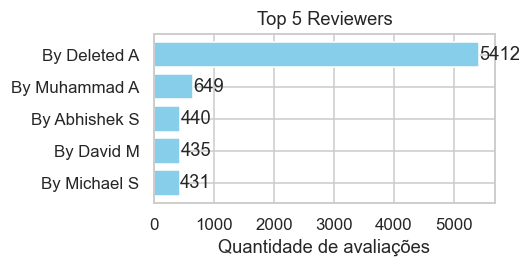

In [120]:
reviews_top(reviews_df)

In [26]:
# Bottom 5 reviewers por quantidade de avaliações
bottom10 = reviews_df['reviewers'].value_counts().tail(5)

print("Bottom 5 reviewers (menos avaliações):")
print(bottom10)

# Ou em formato bonito


Bottom 5 reviewers (menos avaliações):
reviewers
By Calvin N      1
By Kachan O V    1
By Tan S X A     1
By Yusong S      1
By Yu-Jhen-Wu    1
Name: count, dtype: int64


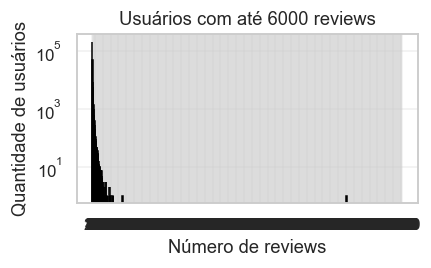

In [128]:

reviews_histogram(reviews_df,6000)

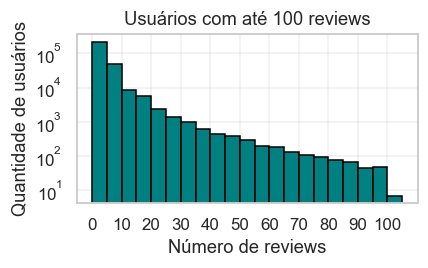

In [129]:
reviews_histogram(reviews_df,100)

Quantos usuários têm entre 51 e 99 reviews: 3364


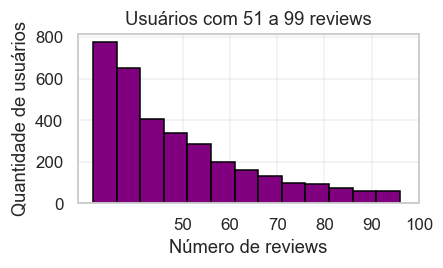


Top 5 nesse intervalo:
reviewers
By Laura S      99
By David O      99
By Jose R       99
By Stephen B    99
By Mark L       99
Name: count, dtype: int64


In [130]:
import matplotlib.pyplot as plt

# Contagem de reviews por usuário
counts = reviews_df['reviewers'].value_counts()

# Filtra apenas 51 a 99 reviews
filtered = counts[(counts > 30) & (counts < 100)]

# Informações básicas
print(f"Quantos usuários têm entre 51 e 99 reviews: {len(filtered)}")

if len(filtered) > 0:
    # Histograma
    plt.figure(figsize=(4, 2))
    plt.hist(filtered, bins=range(31, 101, 5), color='purple', edgecolor='black')
    plt.title('Usuários com 51 a 99 reviews')
    plt.xlabel('Número de reviews')
    plt.ylabel('Quantidade de usuários')
    plt.xticks(range(50, 101, 10))
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Top 5 nesse intervalo (opcional)
    print("\nTop 5 nesse intervalo:")
    print(filtered.head(5))
else:
    print("Nenhum usuário nesse intervalo.")

In [35]:
# Contagem de reviews por usuário
counts = reviews_df['reviewers'].value_counts()

# Estatísticas principais
media = counts.mean()
desvio = counts.std()

print(f"Média de reviews por usuário: {media:.2f}")
print(f"Desvio padrão: {desvio:.2f}")
upper_bound= media + (3*desvio)
print(f"Média + 3σ : {upper_bound:.2f}")


Média de reviews por usuário: 5.05
Desvio padrão: 13.22
Média + 3σ : 44.70


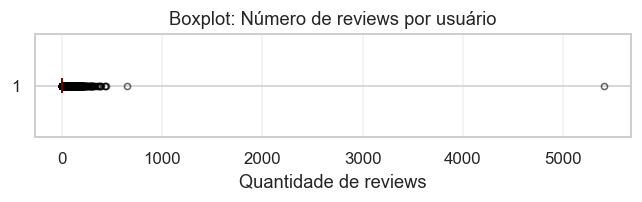

In [131]:
import matplotlib.pyplot as plt

# Contagem de reviews por usuário
counts = reviews_df['reviewers'].value_counts()

# Boxplot horizontal (mais legível com muitos outliers)
plt.figure(figsize=(6, 2))
plt.boxplot(counts, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='darkred'),
            flierprops=dict(marker='o', markersize=4, alpha=0.6))

plt.title('Boxplot: Número de reviews por usuário')
plt.xlabel('Quantidade de reviews')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Contagem de reviews por usuário
counts = reviews_df['reviewers'].value_counts()

# Quintis (0%, 25%, 50%, 75%, 100%) + alguns extras úteis
quintis = counts.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99,0.995,0.999,0.9995, 1.0])

print("Quintis do número de reviews por usuário:")
print(quintis.round(0).astype(int))

Quintis do número de reviews por usuário:
0.0000       1
0.2500       3
0.5000       3
0.7500       4
0.9000       9
0.9500      13
0.9900      36
0.9950      52
0.9990     111
0.9995     144
1.0000    5412
Name: count, dtype: int64


## Conclusão: Não podemos considerar usuário úicos por nome sem filtragem. Abreviaturas e contas apagadas geram distorções.
-Nomes de usuários com mais avaliações de que cursos disponíveis são indicação clara de agregação de várias contas sob um rótulo. 

-Existe uma quantidade razoável de usuários com quantidade factível. O corte abaixo de 100 reviews mostra o limite prárico em 35/40 avaliações por usuário.  

-O uso de 3σ sugere o número 45.

-A divisão por percentis trás concentração razoável até 36 avaliações. Mais que isto só 1% dos usuários.

-Mais do que 52 avaliações são 0.5% dos usuários.

### Abordagem inicial

1. Remoção explícita — remove padrões inválidos conhecidos:
   - "By Deleted A" (e variantes se existirem)
   - Qualquer reviewer com reviews > 623 (impossível ser real)
2. Deduplicação — para o mesmo (reviewer, course_id):
   - Manter apenas a avaliação mais recente
3. Percentil:
   - Corte arbitrário em 99,9% (até 111 reviews)


#### 2.3 Conversão de datas

In [43]:
# Converte a coluna de data para o formato data/hora do pandas
reviews_df['date_reviews'] = pd.to_datetime(
    reviews_df['date_reviews'], format='%b %d, %Y', errors='coerce'
)

# Extrai ano e mês para análises temporais
reviews_df['year'] = reviews_df['date_reviews'].dt.year
reviews_df['month'] = reviews_df['date_reviews'].dt.month
reviews_df['year_month'] = reviews_df['date_reviews'].dt.to_period('M')

# Remove o prefixo "By " do nome dos revisores
reviews_df['reviewer_clean'] = reviews_df['reviewers'].str.replace(r'^By\s+', '', regex=True)

date_failures = reviews_df['date_reviews'].isna().sum()
print(f'Datas que não puderam ser convertidas: {date_failures:,}')
print(f'Período dos dados: {reviews_df["date_reviews"].min().date()} → {reviews_df["date_reviews"].max().date()}')

Datas que não puderam ser convertidas: 0
Período dos dados: 2015-08-07 → 2020-10-10


---
## 3. Análise do Catálogo de Cursos

### 3.1 Distribuição por instituição

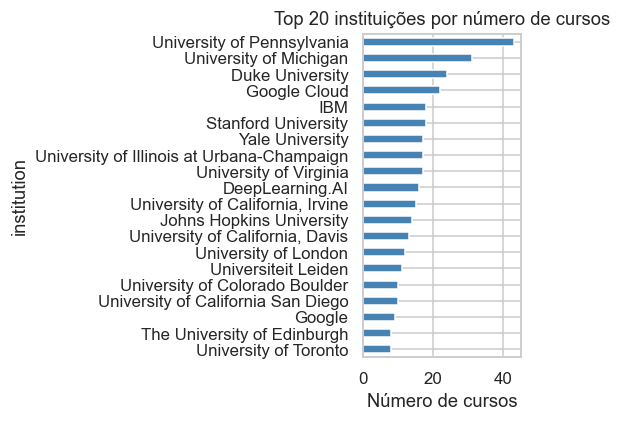

Total de instituições diferentes: 134


In [132]:
# Quantos cursos cada instituição possui
inst_counts = courses_df['institution'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(5, 4))
inst_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Número de cursos')
ax.set_title('Top 20 instituições por número de cursos')
plt.tight_layout()
plt.show()

print(f'Total de instituições diferentes: {courses_df["institution"].nunique()}')

### 3.2 Palavras mais comuns nos nomes dos cursos

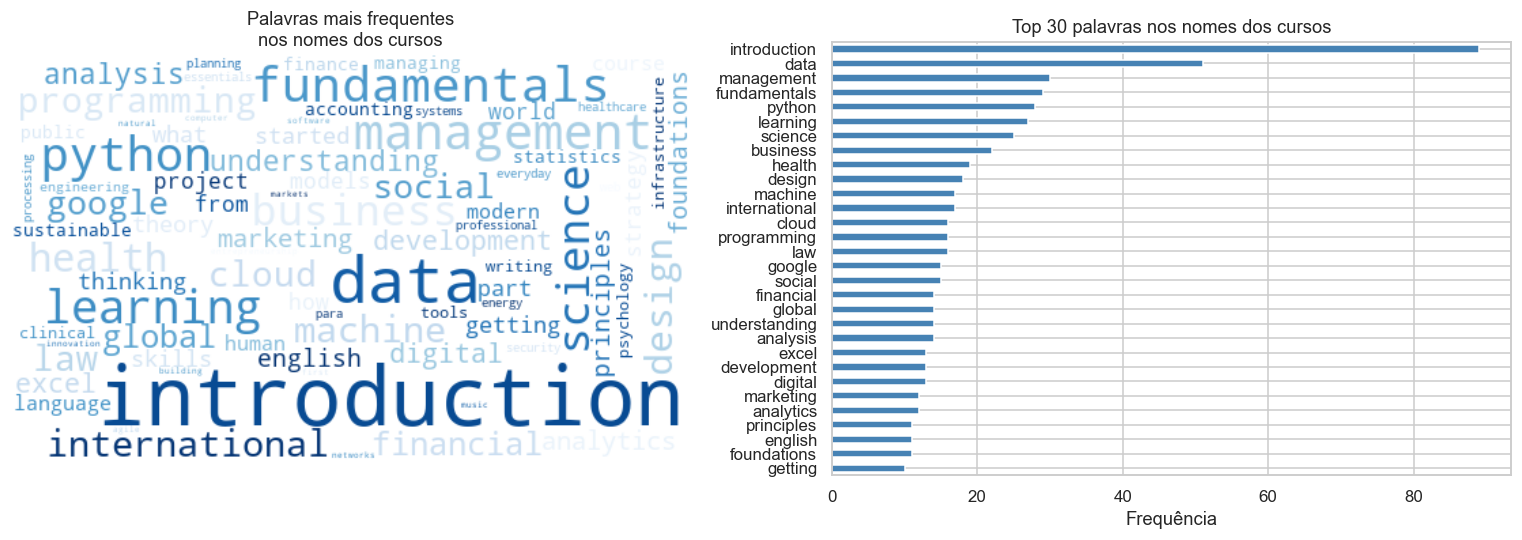

In [45]:
# Palavras a ignorar por serem muito genéricas
stopwords_pt = {'and', 'to', 'in', 'of', 'for', 'a', 'an', 'the', 'with', 'on', 'your', 'you'}

# Separa os nomes dos cursos em palavras e remove as genéricas
all_words = [
    word.lower()
    for name in courses_df['name'].dropna()
    for word in re.findall(r'[a-zA-Z]+', name)
    if word.lower() not in stopwords_pt and len(word) > 2
]

word_freq = Counter(all_words)
top_words = pd.Series(dict(word_freq.most_common(30)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nuvem de palavras
wc = WordCloud(width=500, height=300, background_color='white', colormap='Blues', max_words=80)
wc.generate_from_frequencies(word_freq)
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Palavras mais frequentes\nnos nomes dos cursos')

# Gráfico de barras
top_words.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Frequência')
axes[1].set_title('Top 30 palavras nos nomes dos cursos')

plt.tight_layout()
plt.show()

---
## 4. Distribuição das Notas (Ratings)

### 4.1 Visão geral das notas

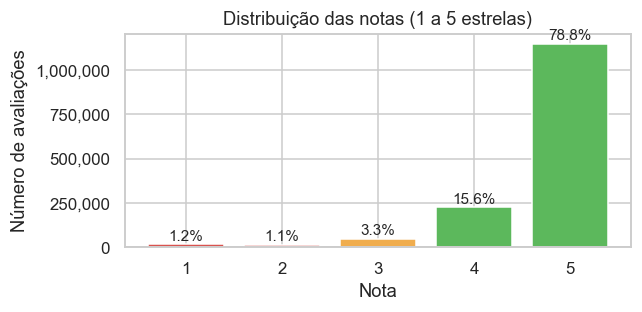

In [134]:
# Contagem e porcentagem de cada nota
rating_counts = reviews_df['rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(reviews_df) * 100).round(1)

# Cores: vermelho para notas baixas, amarelo para médias, verde para altas
bar_colors = ['#d9534f', '#d9534f', '#f0ad4e', '#5cb85c', '#5cb85c']

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='white')

# Adiciona rótulos de porcentagem acima de cada barra
for bar, pct in zip(bars, rating_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f'{pct}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Nota')
ax.set_ylabel('Número de avaliações')
ax.set_title('Distribuição das notas (1 a 5 estrelas)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [47]:
# Estatísticas resumidas das notas
print('Estatísticas das notas:')
print(reviews_df['rating'].describe().to_string())
print(f'\nAssimetria (quanto as notas fogem do centro): {reviews_df["rating"].skew():.3f}')
print('\nObservação: assimetria negativa alta indica que a maioria das notas é 4 ou 5.')

Estatísticas das notas:
count    1.454711e+06
mean     4.696649e+00
std      6.983271e-01
min      1.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00

Assimetria (quanto as notas fogem do centro): -2.977

Observação: assimetria negativa alta indica que a maioria das notas é 4 ou 5.


### 4.2 Distribuição de notas nos 50 cursos mais avaliados

In [ ]:
# Seleciona os 50 cursos com mais avaliações
top_50_courses = reviews_df['course_id'].value_counts().head(50).index
top_reviews = reviews_df[reviews_df['course_id'].isin(top_50_courses)]

# Calcula média e desvio padrão por curso
course_stats_top = (
    top_reviews.groupby('course_id')['rating']
    .agg(media='mean', desvio='std', total='count')
    .reset_index()
    .sort_values('media', ascending=True)  # Revertido: menor no topo
)
# Usa o nome do curso no lugar do ID (quando disponível)
course_stats_top = course_stats_top.merge(
    courses_df[['course_id', 'name']], on='course_id', how='left'
)
course_stats_top['label'] = course_stats_top['name'].fillna(course_stats_top['course_id'])
course_stats_top['label'] = course_stats_top['label'].str[:40] # trunca nomes longos
# Remove linhas inválidas com NaN ou total=0
course_stats_top = course_stats_top.dropna(subset=['media']).query('total > 0').head(30)
# Cor proporcional à média (verde = alta, vermelho = baixa)
norm = plt.Normalize(course_stats_top['media'].min(), course_stats_top['media'].max())
cores = plt.cm.RdYlGn(norm(course_stats_top['media']))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(
    course_stats_top['label'],
    course_stats_top['media'],
    xerr=course_stats_top['desvio'],
    color=cores,
    edgecolor='white',
    capsize=3,
    error_kw={'elinewidth': 0.8, 'ecolor': 'gray'}
)
# Anota o total de avaliações à direita de cada barra
for i, row in course_stats_top.iterrows():
    ax.text(
        row['media'] + row['desvio'] + 0.05,
        i,
        f"±{row['desvio']:.2f} n={row['total']:,}",
        va='center', fontsize=7, color='gray'
    )
ax.set_xlabel('Nota média (± desvio padrão)')
ax.set_title('Top 30 cursos mais avaliados — nota média')
ax.set_xlim(0, 5.8)
ax.axvline(4, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()


---
## 5. Volume de Avaliações e Distribuição de Dados

### 5.1 Quantas avaliações cada curso tem

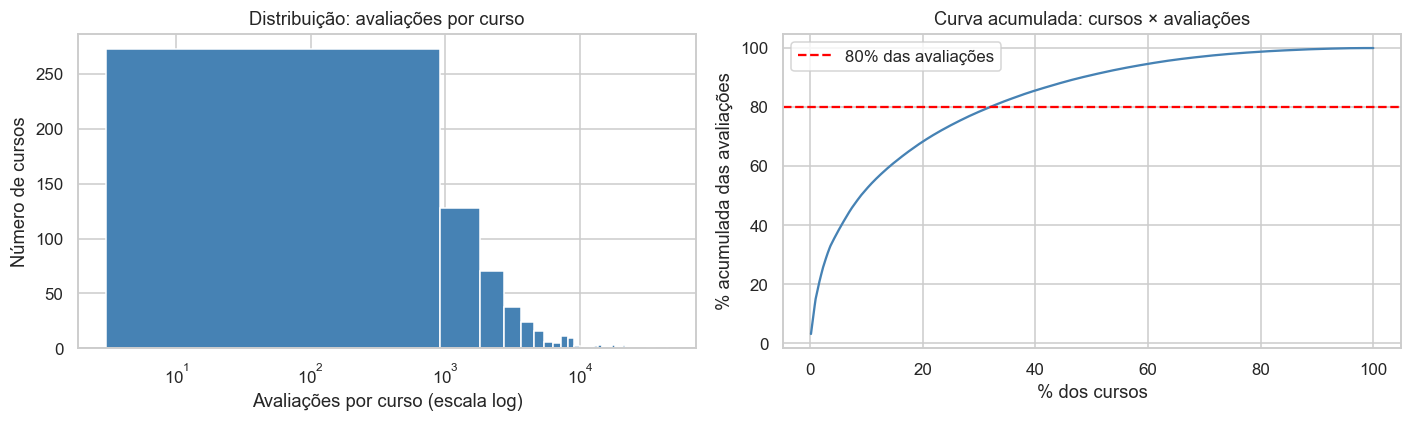

32.0% dos cursos concentram 80% de todas as avaliações.
Isso equivale a 193 cursos de 604 no total.


In [69]:
# Número de avaliações por curso
reviews_per_course = reviews_df.groupby('course_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma em escala logarítmica
axes[0].hist(reviews_per_course, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Avaliações por curso (escala log)')
axes[0].set_ylabel('Número de cursos')
axes[0].set_title('Distribuição: avaliações por curso')

# Curva acumulada
sorted_vals = np.sort(reviews_per_course.values)[::-1]
cum_pct = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
course_pct = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals) * 100
axes[1].plot(course_pct, cum_pct, color='steelblue')
axes[1].axhline(80, color='red', linestyle='--', label='80% das avaliações')
axes[1].set_xlabel('% dos cursos')
axes[1].set_ylabel('% acumulada das avaliações')
axes[1].set_title('Curva acumulada: cursos × avaliações')
axes[1].legend()

plt.tight_layout()
plt.show()

# Onde está o limite de 80%?
threshold_idx = np.searchsorted(cum_pct, 80)
threshold_pct = course_pct[threshold_idx]
print(f'{threshold_pct:.1f}% dos cursos concentram 80% de todas as avaliações.')
print(f'Isso equivale a {threshold_idx + 1} cursos de {len(sorted_vals)} no total.')

### 5.2 Densidade da matriz de avaliações

In [93]:
# Calcula a densidade dos dados (quanto da matriz usuário × curso está preenchido)
n_users = reviews_df['reviewer_clean'].nunique()
n_courses = reviews_df['course_id'].nunique()
n_ratings = len(reviews_df)

density = n_ratings / (n_users * n_courses) * 100
sparsity = 100 - density

print(f'Usuários únicos:        {n_users:>12,}')
print(f'Cursos únicos:          {n_courses:>12,}')
print(f'Total de avaliações:    {n_ratings:>12,}')
print(f'Total possível:         {n_users * n_courses:>12,}')
print(f'Densidade dos dados:    {density:>11.4f}%')
print(f'Esparsidade:         {sparsity:>11.4f}%')
print()


Usuários únicos:             287,668
Cursos únicos:                   604
Total de avaliações:       1,454,711
Total possível:          173,751,472
Densidade dos dados:         0.8372%
Esparsidade:             99.1628%



### Esparsidade
Uma base de avaliações extremamente esparsa, com pouca cobertura de curso pelos usuários. Será necessário combinar intensões de usuários com descrições de cursos.

### 5.3 Cursos com avaliações mas sem cadastro no catálogo

In [72]:
# Identificar cursos que aparecem nas avaliações mas não no catálogo
course_ids_reviews = set(reviews_df['course_id'].unique())
course_ids_catalog = set(courses_df['course_id'].unique())

orphan_courses = course_ids_reviews - course_ids_catalog
in_catalog = course_ids_reviews & course_ids_catalog

print(f'Cursos no catálogo:                     {len(course_ids_catalog):,}')
print(f'Cursos com ao menos uma avaliação:      {len(course_ids_reviews):,}')
print(f'Cursos com avaliações E no catálogo:    {len(in_catalog):,}')
print(f'Cursos com avaliações MAS sem cadastro: {len(orphan_courses):,}')

# Quantas avaliações são desses cursos sem cadastro?
orphan_rev_count = reviews_df[reviews_df['course_id'].isin(orphan_courses)].shape[0]
print(f'\nAvaliações de cursos sem cadastro: {orphan_rev_count:,} ({orphan_rev_count/n_ratings*100:.1f}% do total)')

Cursos no catálogo:                     623
Cursos com ao menos uma avaliação:      604
Cursos com avaliações E no catálogo:    604
Cursos com avaliações MAS sem cadastro: 0

Avaliações de cursos sem cadastro: 0 (0.0% do total)


---
## 6. Análise Temporal das Avaliações

### 6.1 Volume de avaliações ao longo do tempo

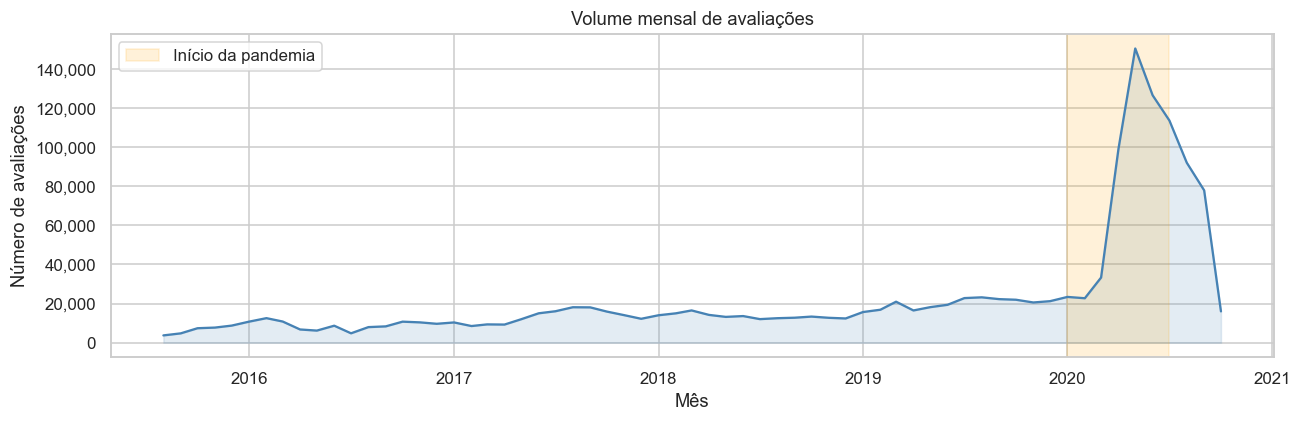

In [73]:
# Avaliações por mês
monthly_counts = reviews_df.groupby('year_month').size()
monthly_idx = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_idx, monthly_counts.values, color='steelblue', linewidth=1.5)
ax.fill_between(monthly_idx, monthly_counts.values, alpha=0.15, color='steelblue')

# Destaca o período da pandemia (início de 2020 até meados de 2020)
try:
    import matplotlib.dates as mdates
    from datetime import datetime
    covid_start = mdates.date2num(datetime(2020, 1, 1))
    covid_end   = mdates.date2num(datetime(2020, 7, 1))
    ax.axvspan(datetime(2020, 1, 1), datetime(2020, 7, 1),
               alpha=0.15, color='orange', label='Início da pandemia')
    ax.legend()
except Exception:
    pass

ax.set_xlabel('Mês')
ax.set_ylabel('Número de avaliações')
ax.set_title('Volume mensal de avaliações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### 6.2 Nota média ao longo do tempo

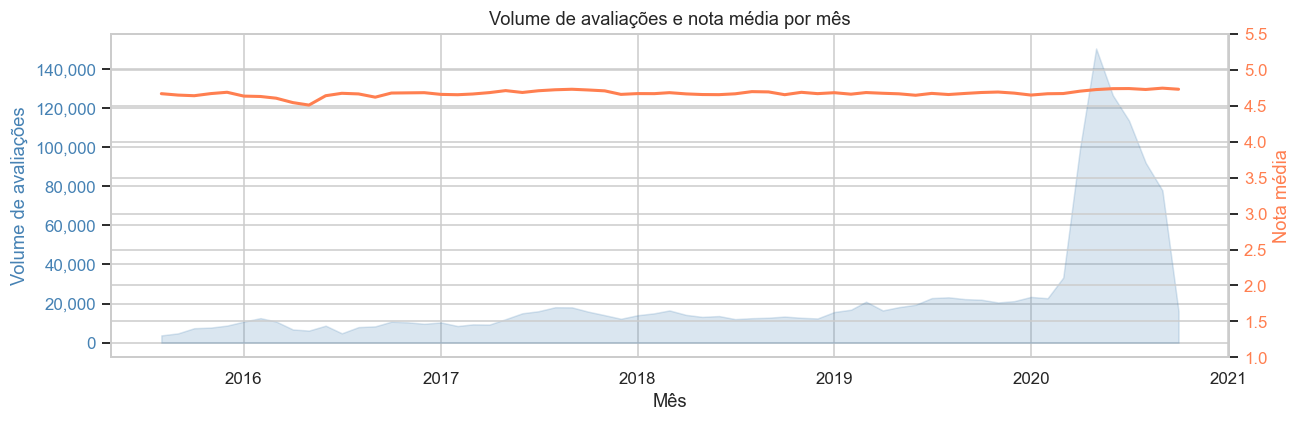

In [74]:
# Nota média mensal
monthly_rating = reviews_df.groupby('year_month')['rating'].mean()
monthly_rating_idx = monthly_rating.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 4))

# Eixo esquerdo: volume
ax1.fill_between(monthly_idx, monthly_counts.values, alpha=0.2, color='steelblue')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Volume de avaliações', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Eixo direito: nota média
ax2 = ax1.twinx()
ax2.plot(monthly_rating_idx, monthly_rating.values, color='coral', linewidth=2)
ax2.set_ylabel('Nota média', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')
ax2.set_ylim(1, 5.5)

plt.title('Volume de avaliações e nota média por mês')
plt.tight_layout()
plt.show()

### 6.3 Cursos mais populares por período

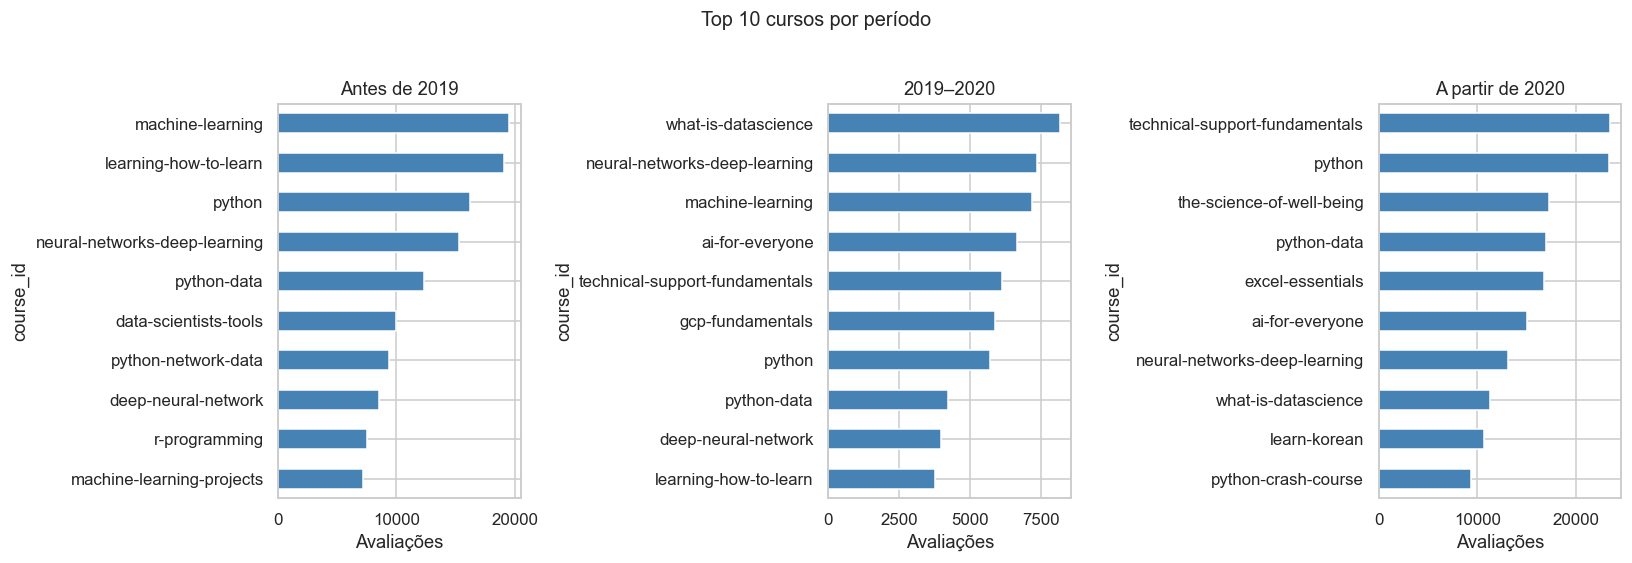

In [75]:
# Define três períodos: antes de 2019, 2019-2020 e a partir de 2020
periods = {
    'Antes de 2019': reviews_df[reviews_df['year'] < 2019],
    '2019–2020':     reviews_df[(reviews_df['year'] >= 2019) & (reviews_df['year'] < 2020)],
    'A partir de 2020': reviews_df[reviews_df['year'] >= 2020],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (period_name, period_data) in zip(axes, periods.items()):
    top = period_data['course_id'].value_counts().head(10).sort_values()
    top.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(period_name)
    ax.set_xlabel('Avaliações')

plt.suptitle('Top 10 cursos por período', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Comportamento dos Usuários

### 7.1 Tendência de dar notas altas

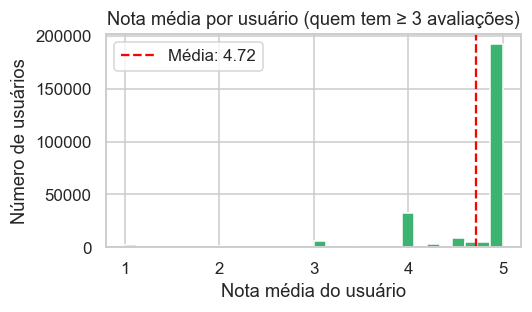

In [137]:
# Para usuários com 3 ou mais avaliações, calcula a nota média de cada um
user_means = (
    reviews_df.groupby('reviewer_clean')['rating']
    .agg(['mean', 'count'])
    .query('count >= 3')
)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(user_means['mean'], bins=30, color='mediumseagreen', edgecolor='white')
ax.axvline(user_means['mean'].mean(), color='red', linestyle='--',
           label=f'Média: {user_means["mean"].mean():.2f}')
ax.set_xlabel('Nota média do usuário')
ax.set_ylabel('Número de usuários')
ax.set_title('Nota média por usuário (quem tem ≥ 3 avaliações)')
ax.legend()
plt.tight_layout()
plt.show()

pct_above_4 = (user_means['mean'] >= 4).mean() * 100


### Viés de avaliação
95.2% dos usuários têm nota média ≥ 4
As notas são muito positivas no geral. Para comparar usuários com justiça,
o ideal é subtrair normalizar as médias de um usuário')

### 7.2 Por quanto tempo os usuários ficam ativos

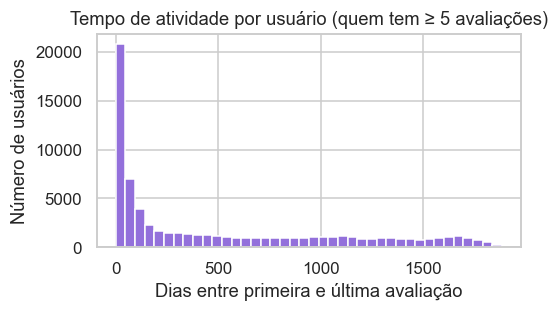

Mediana de dias ativos: 222 dias (7.4 meses)


In [138]:
# Para usuários com 5 ou mais avaliações, calcula quantos dias ficaram ativos
user_timeline = (
    reviews_df.dropna(subset=['date_reviews'])
    .groupby('reviewer_clean')['date_reviews']
    .agg(['min', 'max', 'count'])
    .query('count >= 5')
)
user_timeline['active_days'] = (user_timeline['max'] - user_timeline['min']).dt.days

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(user_timeline['active_days'], bins=40, color='mediumpurple', edgecolor='white')
ax.set_xlabel('Dias entre primeira e última avaliação')
ax.set_ylabel('Número de usuários')
ax.set_title('Tempo de atividade por usuário (quem tem ≥ 5 avaliações)')
plt.tight_layout()
plt.show()

median_days = user_timeline['active_days'].median()
print(f'Mediana de dias ativos: {median_days:.0f} dias ({median_days/30:.1f} meses)')

---
## 8. Análise do Texto das Avaliações


In [108]:
# Cria uma amostra balanceada por nota para analisar o texto
frac = SAMPLE_SIZE / len(reviews_df)
sample_df = (
    reviews_df.dropna(subset=['reviews'])
    .groupby('rating', group_keys=False)
    .apply(lambda x: x.sample(frac=frac, random_state=42))
    .reset_index(drop=True)
)

# Calcula tamanho das avaliações em caracteres e palavras
sample_df['review_length'] = sample_df['reviews'].str.len()
sample_df['word_count']    = sample_df['reviews'].str.split().str.len()

print(f'Tamanho da amostra: {len(sample_df):,} avaliações')

Tamanho da amostra: 599,937 avaliações


### 8.1 Tamanho das avaliações por nota

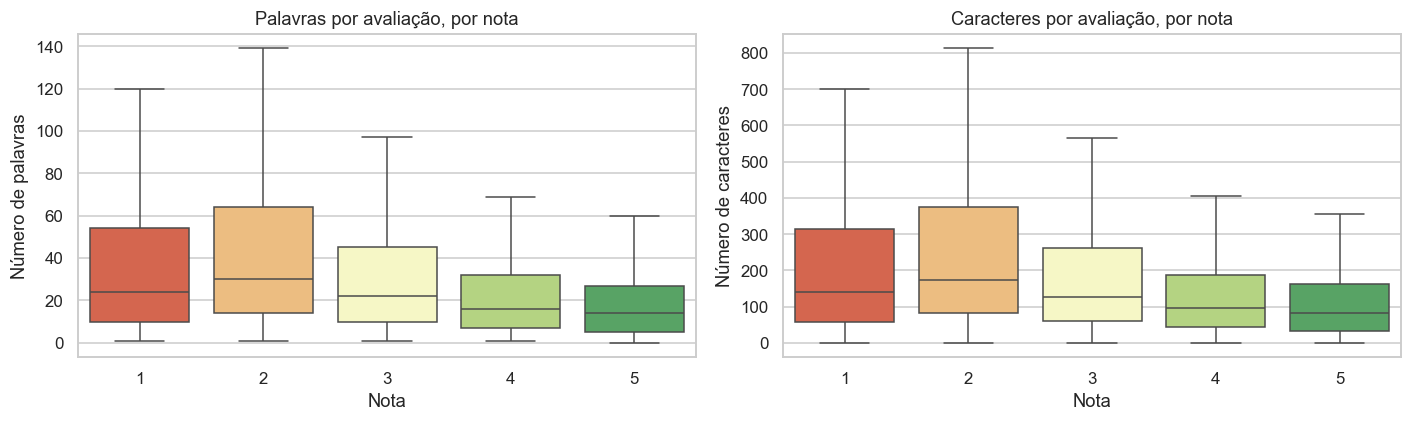

Média de palavras por nota:
rating
1    42.9
2    50.3
3    34.6
4    25.2
5    20.6


In [107]:
# Compara o número de palavras entre notas diferentes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=sample_df, x='rating', y='word_count', ax=axes[0],
            palette='RdYlGn', showfliers=False)
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Número de palavras')
axes[0].set_title('Palavras por avaliação, por nota')

sns.boxplot(data=sample_df, x='rating', y='review_length', ax=axes[1],
            palette='RdYlGn', showfliers=False)
axes[1].set_xlabel('Nota')
axes[1].set_ylabel('Número de caracteres')
axes[1].set_title('Caracteres por avaliação, por nota')

plt.tight_layout()
plt.show()

print('Média de palavras por nota:')
print(sample_df.groupby('rating')['word_count'].mean().round(1).to_string())

### 8.2 Nuvens de palavras por sentimento

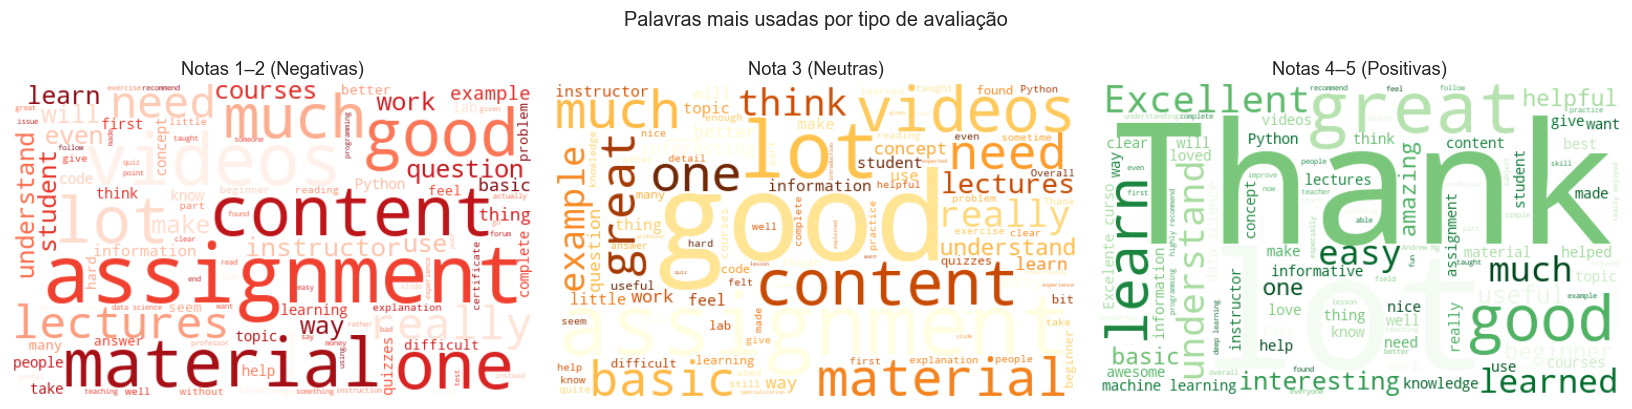

In [109]:
# Palavras a ignorar por serem muito comuns e pouco informativas
extra_stopwords = STOPWORDS | {'course', 'coursera', 'class', 'lecture', 'video', 'week', 'time'}

def build_wordcloud(texts, colormap):
    """Cria uma nuvem de palavras a partir de uma lista de textos."""
    combined = ' '.join(texts.dropna())
    wc = WordCloud(
        width=500, height=300,
        background_color='white',
        stopwords=extra_stopwords,
        colormap=colormap,
        max_words=100
    )
    return wc.generate(combined)

# Separa avaliações negativas, neutras e positivas
neg_texts     = sample_df[sample_df['rating'] <= 2]['reviews']
neutral_texts = sample_df[sample_df['rating'] == 3]['reviews']
pos_texts     = sample_df[sample_df['rating'] >= 4]['reviews']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, texts, cmap, title in zip(
    axes,
    [neg_texts, neutral_texts, pos_texts],
    ['Reds', 'YlOrBr', 'Greens'],
    ['Notas 1–2 (Negativas)', 'Nota 3 (Neutras)', 'Notas 4–5 (Positivas)']
):
    wc = build_wordcloud(texts, cmap)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

plt.suptitle('Palavras mais usadas por tipo de avaliação', fontsize=13)
plt.tight_layout()
plt.show()

### 8.3 Pares de palavras mais frequentes (bigramas)

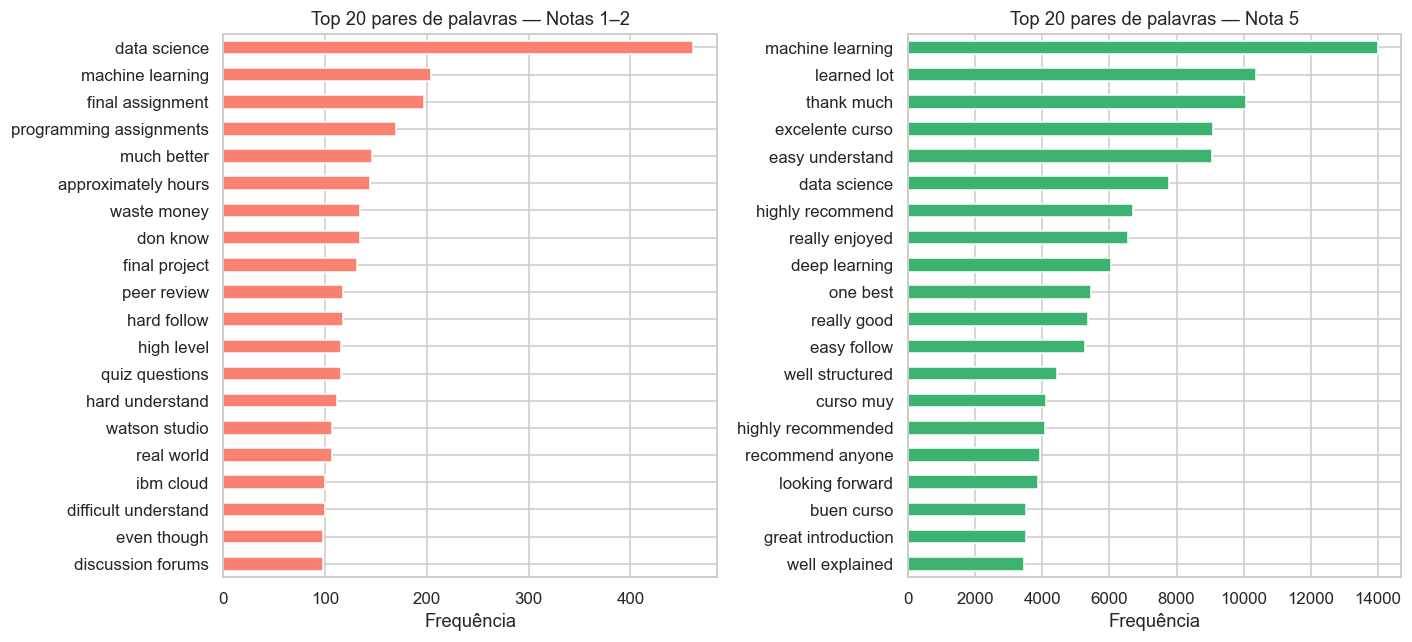

In [110]:
def get_bigrams(texts, top_n=20):
    """Extrai os pares de palavras mais frequentes de uma lista de textos."""
    tokens_list = [
        [w.lower() for w in re.findall(r'[a-zA-Z]+', str(text))
         if w.lower() not in extra_stopwords and len(w) > 2]
        for text in texts.dropna()
    ]
    bigrams = Counter(
        bigram
        for tokens in tokens_list
        for bigram in zip(tokens, tokens[1:])
    )
    top = pd.Series({' '.join(k): v for k, v in bigrams.most_common(top_n)})
    return top.sort_values()

neg_bigrams = get_bigrams(sample_df[sample_df['rating'] <= 2]['reviews'])
pos_bigrams = get_bigrams(sample_df[sample_df['rating'] == 5]['reviews'])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

neg_bigrams.plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('Top 20 pares de palavras — Notas 1–2')
axes[0].set_xlabel('Frequência')

pos_bigrams.plot(kind='barh', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Top 20 pares de palavras — Nota 5')
axes[1].set_xlabel('Frequência')

plt.tight_layout()
plt.show()

### 8.4 Avaliações muito curtas (pouco informativas)

In [111]:
# Avaliações com menos de 5 palavras que se repetem muito
short_reviews = sample_df[sample_df['word_count'] < 5]['reviews'].value_counts().head(20)

print('As 20 avaliações curtas mais repetidas:')
print(short_reviews.to_string())
print()
short_pct = (sample_df['word_count'] < 5).mean() * 100
print(f'Avaliações com menos de 5 palavras: {short_pct:.1f}% da amostra')
print('→ Essas avaliações curtas têm pouco valor para análise de texto e serão')
print('  filtradas na etapa de pré-processamento.')

As 20 avaliações curtas mais repetidas:
reviews
good                 3680
Good                 2240
Excellent            1525
Great course!         975
great                 911
nice                  844
very good             835
Great course          825
Excellent course      823
excellent             814
Great                 766
great course          665
Excellent!            626
good course           596
Excellent course!     507
Nice                  505
Good course           494
Awesome               494
Great!                476
Excelente             471

Avaliações com menos de 5 palavras: 20.0% da amostra
→ Essas avaliações curtas têm pouco valor para análise de texto e serão
  filtradas na etapa de pré-processamento.


---
## 9. Métricas por Curso

In [112]:
# Calcula métricas resumidas para cada curso
course_stats = (
    reviews_df.groupby('course_id')
    .agg(
        review_count=('rating', 'count'),
        mean_rating=('rating', 'mean'),
        std_rating=('rating', 'std'),
        median_rating=('rating', 'median'),
        pct_5star=('rating', lambda x: (x == 5).mean()),
        pct_1star=('rating', lambda x: (x == 1).mean()),
    )
    .reset_index()
)

# Adiciona nome e instituição do catálogo
course_stats = course_stats.merge(courses_df[['course_id', 'name', 'institution']], on='course_id', how='left')

print('Top 10 cursos com mais avaliações:')
display(course_stats.nlargest(10, 'review_count')[['name', 'institution', 'review_count', 'mean_rating']].reset_index(drop=True))

print('\nTop 10 cursos mais bem avaliados (com ≥ 100 avaliações):')
display(
    course_stats[course_stats['review_count'] >= 100]
    .nlargest(10, 'mean_rating')[['name', 'institution', 'review_count', 'mean_rating']]
    .reset_index(drop=True)
)

Top 10 cursos com mais avaliações:


,name,institution,review_count,mean_rating
0,Programming for Everybody (Getting Started with Python),University of Michigan,45218,4.581782
1,Machine Learning,Stanford University,35895,4.750522
2,Neural Networks and Deep Learning,DeepLearning.AI,35750,4.775888
3,Technical Support Fundamentals,Google,35319,4.776183
4,Python Data Structures,University of Michigan,33546,4.846629
5,Learning How to Learn: Powerful mental tools to help you master tough subjects,University of California San Diego,32265,4.802139
6,AI For Everyone,DeepLearning.AI,21630,4.843551
7,Excel Skills for Business: Essentials,Macquarie University,21251,4.895534
8,What is Data Science?,IBM,21087,4.632665
9,The Science of Well-Being,Yale University,20085,4.928404



Top 10 cursos mais bem avaliados (com ≥ 100 avaliações):


,name,institution,review_count,mean_rating
0,El Abogado del Futuro: Legaltech y la Transformación Digital del Derecho,Universidad Austral,375,4.968000
1,Développement psychologique de l'enfant,University of Geneva,255,4.964706
2,The Horse Course: Introduction to Basic Care and Management,University of Florida,774,4.957364
3,Build a Modern Computer from First Principles: Nand to Tetris Part II (project-centered course),Hebrew University of Jerusalem,279,4.956989
4,Bugs 101: Insect-Human Interactions,University of Alberta,747,4.955823
5,Economics of Money and Banking,Columbia University,813,4.955720
6,Cursos en línea: modelo para armar,Universidad Nacional Autónoma de México,164,4.951220
7,"Everyday Excel, Part 2",University of Colorado Boulder,120,4.950000
8,Equine Welfare and Management,"University of California, Davis",158,4.949367
9,Corporate Strategy,UCL School of Management,348,4.948276


### 9.1 Popularidade × Qualidade

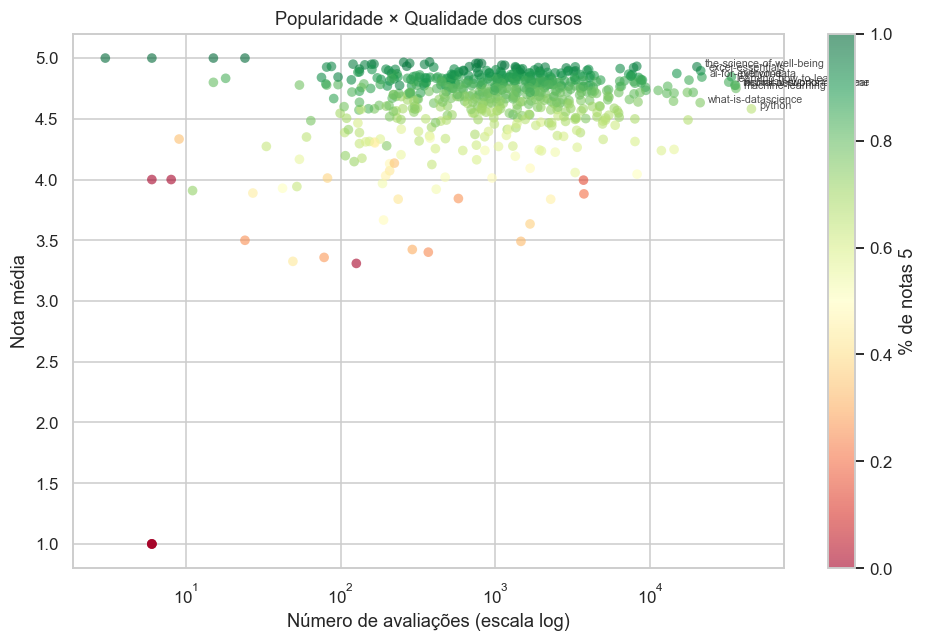

In [113]:
# Gráfico de dispersão: número de avaliações × nota média
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    course_stats['review_count'],
    course_stats['mean_rating'],
    c=course_stats['pct_5star'],
    cmap='RdYlGn', alpha=0.6, s=40, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='% de notas 5')

ax.set_xscale('log')
ax.set_xlabel('Número de avaliações (escala log)')
ax.set_ylabel('Nota média')
ax.set_title('Popularidade × Qualidade dos cursos')

# Rotula os 10 cursos com mais avaliações
top10 = course_stats.nlargest(10, 'review_count')
for _, row in top10.iterrows():
    label = str(row['course_id'])[:25]
    ax.annotate(label, (row['review_count'], row['mean_rating']),
                fontsize=7, alpha=0.8, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

### 9.2 Cursos mais polêmicos (alta variação nas notas)

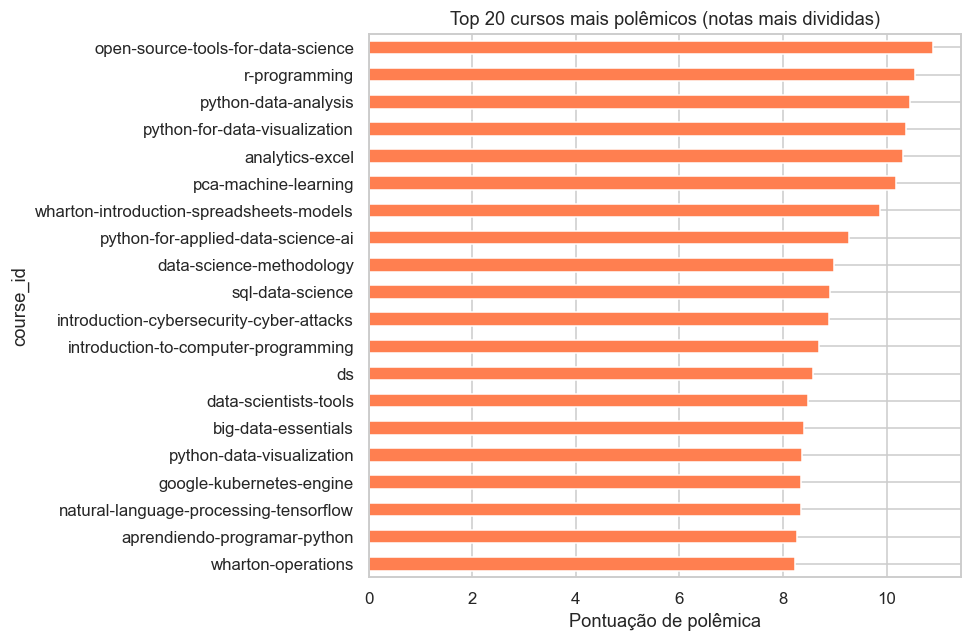

In [114]:
# Um curso polêmico tem notas muito variadas (alguns adoram, outros odeiam)
# Combina variação com volume: mais avaliações = mais relevante
course_stats['controversy_score'] = course_stats['std_rating'] * np.log1p(course_stats['review_count'])

top_controversial = (
    course_stats.dropna(subset=['std_rating'])
    .nlargest(20, 'controversy_score')
    [['course_id', 'review_count', 'mean_rating', 'std_rating', 'controversy_score']]
)

fig, ax = plt.subplots(figsize=(9, 6))
top_controversial.set_index('course_id')['controversy_score'].sort_values().plot(
    kind='barh', ax=ax, color='coral'
)
ax.set_xlabel('Pontuação de polêmica')
ax.set_title('Top 20 cursos mais polêmicos (notas mais divididas)')
plt.tight_layout()
plt.show()

### 9.3 Reputação das instituições

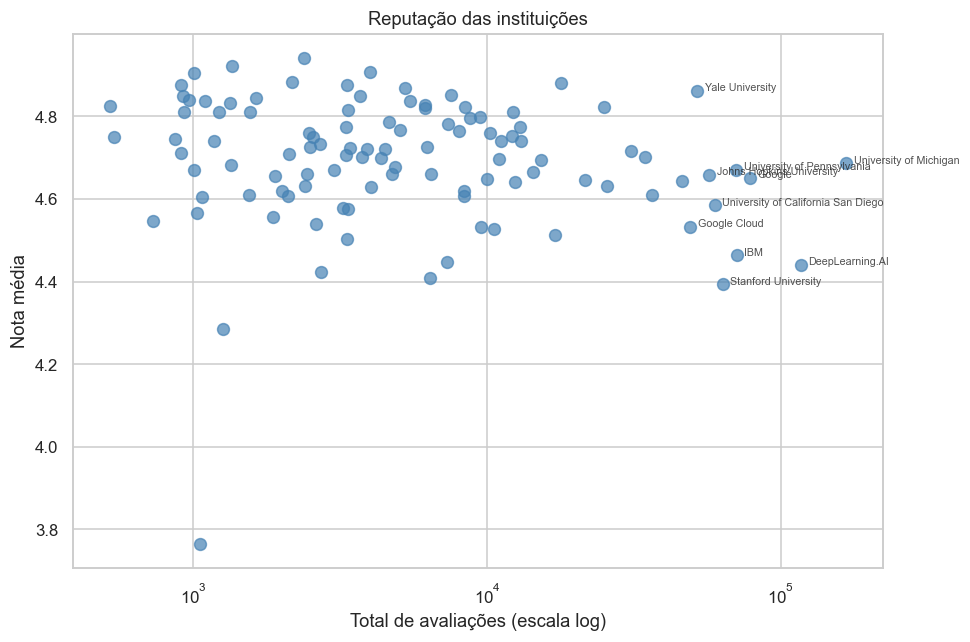

In [115]:
# Nota média e volume total de avaliações por instituição
institution_stats = (
    course_stats.dropna(subset=['institution'])
    .groupby('institution')
    .agg(total_reviews=('review_count', 'sum'), mean_rating=('mean_rating', 'mean'))
    .reset_index()
    .query('total_reviews >= 500')  # apenas instituições com volume relevante
)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    institution_stats['total_reviews'],
    institution_stats['mean_rating'],
    alpha=0.7, s=60, color='steelblue'
)
ax.set_xscale('log')
ax.set_xlabel('Total de avaliações (escala log)')
ax.set_ylabel('Nota média')
ax.set_title('Reputação das instituições')

# Rotula as 10 maiores
top10_inst = institution_stats.nlargest(10, 'total_reviews')
for _, row in top10_inst.iterrows():
    ax.annotate(row['institution'], (row['total_reviews'], row['mean_rating']),
                fontsize=7, alpha=0.8, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

---
## 10. Análise Combinada: Cursos + Avaliações

### 10.1 Avaliações por instituição

Cobertura do catálogo: 100.0% das avaliações têm curso cadastrado


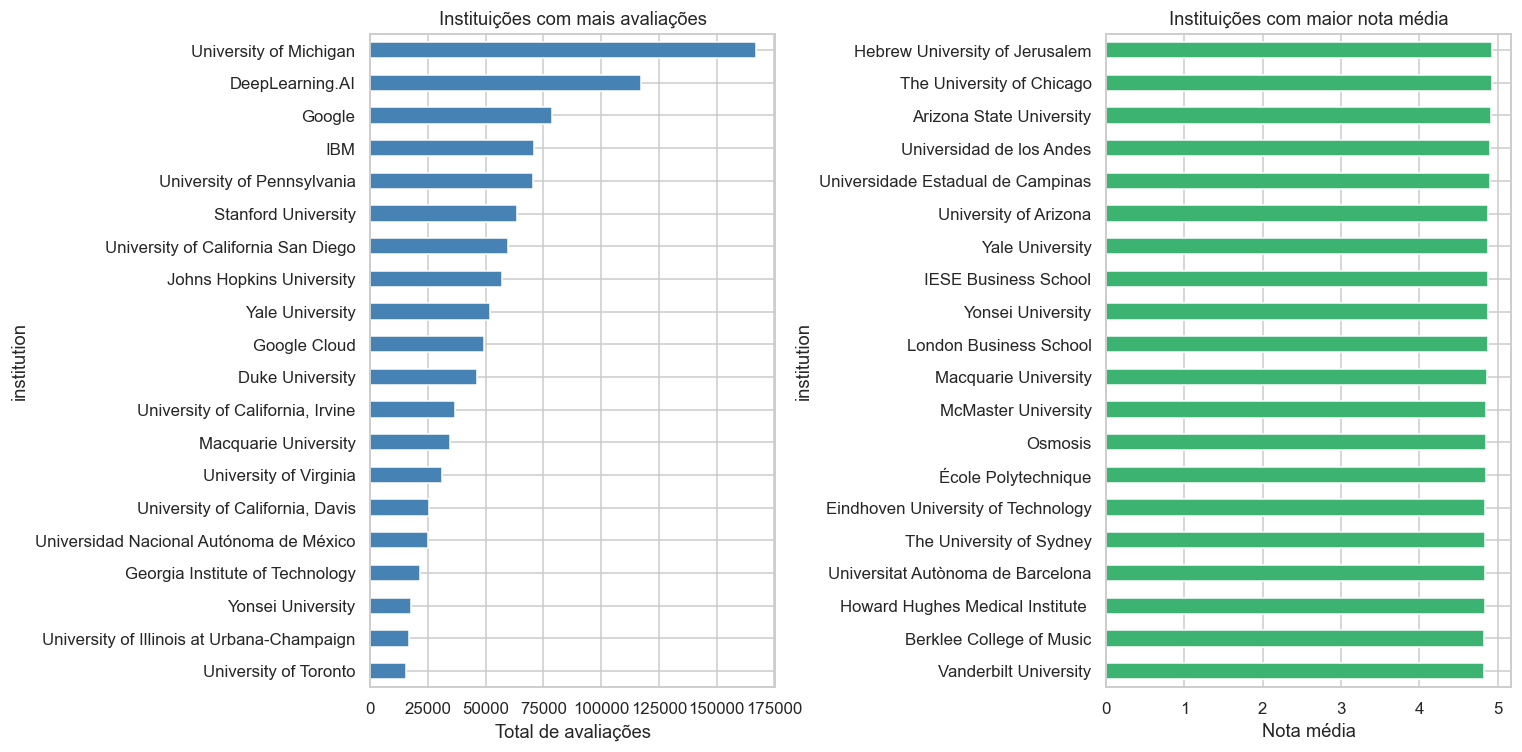

In [116]:
# Junta os datasets e calcula métricas por instituição
merged_df = reviews_df.merge(courses_df[['course_id', 'name', 'institution']], on='course_id', how='left')

coverage = merged_df['name'].notna().mean() * 100
print(f'Cobertura do catálogo: {coverage:.1f}% das avaliações têm curso cadastrado')

# Métricas por instituição
inst_metrics = (
    merged_df.dropna(subset=['institution'])
    .groupby('institution')
    .agg(total_reviews=('rating', 'count'), mean_rating=('rating', 'mean'))
    .query('total_reviews >= 1000')
    .sort_values('total_reviews', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

inst_metrics['total_reviews'].tail(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Total de avaliações')
axes[0].set_title('Instituições com mais avaliações')

inst_metrics.sort_values('mean_rating', ascending=True).tail(20)['mean_rating'].plot(
    kind='barh', ax=axes[1], color='mediumseagreen'
)
axes[1].set_xlabel('Nota média')
axes[1].set_title('Instituições com maior nota média')

plt.tight_layout()
plt.show()

### 10.2 Classificação dos cursos em quatro grupos

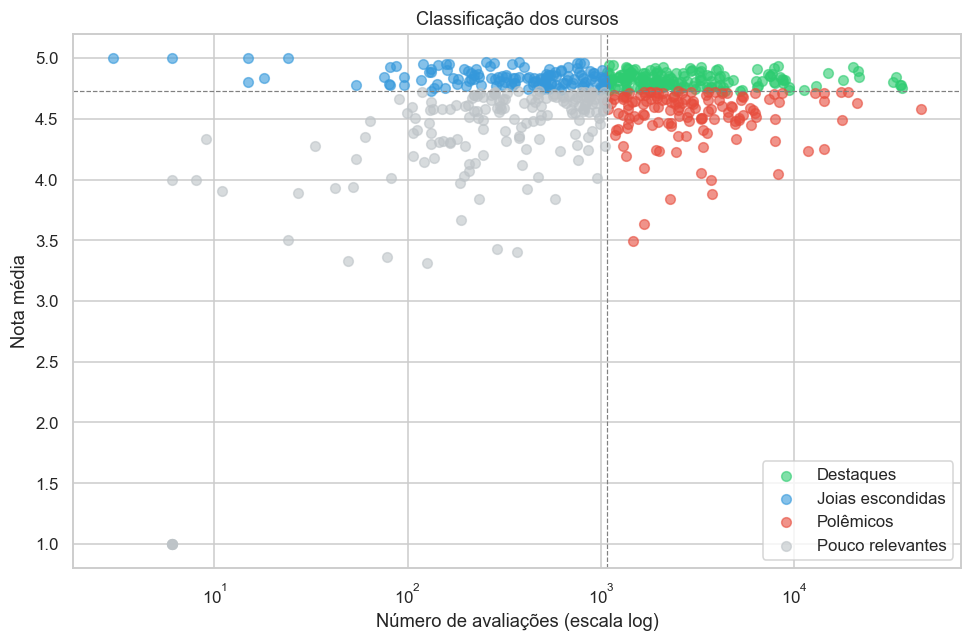

Distribuição dos grupos:
group
Destaques           166
Pouco relevantes    166
Polêmicos           136
Joias escondidas    136


In [117]:
# Classifica os cursos com base em volume e qualidade
median_volume = course_stats['review_count'].median()
median_quality = course_stats['mean_rating'].median()

def classify_course(row):
    """Classifica o curso em um dos quatro grupos."""
    high_vol  = row['review_count'] >= median_volume
    high_qual = row['mean_rating']  >= median_quality
    if high_vol and high_qual:      return 'Destaques'
    if high_vol and not high_qual:  return 'Polêmicos'
    if not high_vol and high_qual:  return 'Joias escondidas'
    return 'Pouco relevantes'

course_stats['group'] = course_stats.apply(classify_course, axis=1)

# Gráfico de dispersão com os quatro grupos
group_colors = {
    'Destaques':        '#2ecc71',
    'Polêmicos':        '#e74c3c',
    'Joias escondidas': '#3498db',
    'Pouco relevantes': '#bdc3c7',
}

fig, ax = plt.subplots(figsize=(9, 6))
for group_name, group_data in course_stats.groupby('group'):
    ax.scatter(
        group_data['review_count'],
        group_data['mean_rating'],
        label=group_name,
        color=group_colors[group_name],
        alpha=0.6, s=40
    )

ax.axvline(median_volume, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(median_quality, color='gray', linestyle='--', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('Número de avaliações (escala log)')
ax.set_ylabel('Nota média')
ax.set_title('Classificação dos cursos')
ax.legend()
plt.tight_layout()
plt.show()

print('Distribuição dos grupos:')
print(course_stats['group'].value_counts().to_string())